# Sophronia : Example of how to access the Sophronia hits

January 2026

* [IC socumentation](https://next-exp-sw.readthedocs.io/en/latest/index.html#)
* [Sophronia documentaion](https://next-exp-sw.readthedocs.io/en/latest/sophronia.html)

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

In [2]:
import glob
import sys
from os import listdir
from collections import namedtuple
import itertools as itertools

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize
import networkx as nx

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
#datafilename = 'dataset_15607_DEP_deco.h5'
#mcfilename   = 'dataset_4bar_MC_DEP_deco.h5'
data_path = "/mnt/netapp1/Store_next_data/NEXT100/data"
filename  = "/15607/hdf5/prod/v2.3.1/20250717/sophronia/trigger2/ldc1/run_15607_0000_ldc1_trg2.v2.3.1.20250717.HEDesman.sophronia.h5"

In [5]:
## Inspect the structure of the data files
with tb.open_file(data_path + filename, 'r') as h5in:
    print(h5in)

/mnt/netapp1/Store_next_data/NEXT100/data/15607/hdf5/prod/v2.3.1/20250717/sophronia/trigger2/ldc1/run_15607_0000_ldc1_trg2.v2.3.1.20250717.HEDesman.sophronia.h5 (File) ''
Last modif.: 'Tue Jul 22 09:49:51 2025'
Object Tree: 
/ (RootGroup) ''
/DB (Group) ''
/DB/DataPMT (Table(60,), shuffle, zlib(4)) 'DB constants for PMTs'
/DB/DataSiPM (Table(3584,), shuffle, zlib(4)) 'DB constants for SiPMs'
/DST (Group) ''
/DST/Events (Table(90,), shuffle, zlib(4)) 'KDST Events'
/Filters (Group) ''
/Filters/s12_selector (Table(30,), shuffle, zlib(4)) 'Event has passed filter flag'
/Filters/valid_hit (Table(30,), shuffle, zlib(4)) 'Event has passed filter flag'
/RECO (Group) ''
/RECO/Events (Table(46240,), shuffle, zlib(4)) 'Hits'
/Run (Group) ''
/Run/events (Table(30,), shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(30,), shuffle, zlib(4)) 'run info table'



In [6]:
hits = pd.read_hdf(data_path + filename, 'RECO/Events')

In [11]:
hits.head()

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,15,1.752993e+09,36,72.292775,69.919261,1,-235.825,-402.175,0.0,0.0,724.462375,8.049496,-0.486855,-1.0,-0.000004,-1,-1.0
1,15,1.752993e+09,36,72.292775,69.919261,1,-3.575,414.975,0.0,0.0,724.462375,6.255112,-0.378326,-1.0,-0.000002,-1,-1.0
2,15,1.752993e+09,36,72.292775,69.919261,1,257.775,-340.475,0.0,0.0,724.462375,5.950277,-0.359889,-1.0,-0.000002,-1,-1.0
3,15,1.752993e+09,36,72.292775,69.919261,1,319.975,-418.225,0.0,0.0,724.462375,7.132378,-0.431385,-1.0,NaN,-1,-1.0
4,15,1.752993e+09,36,72.292775,69.919261,1,366.625,-324.925,0.0,0.0,724.462375,6.428333,-0.388803,-1.0,NaN,-1,-1.0


In [15]:
pypaths = ('/home/usc/ie/jhm/NEXT/nextana',
           '/home/usc/ie/jhm/NEXT/hipy', 
           '/home/usc/ie/jjhm/NEXT/IC')
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

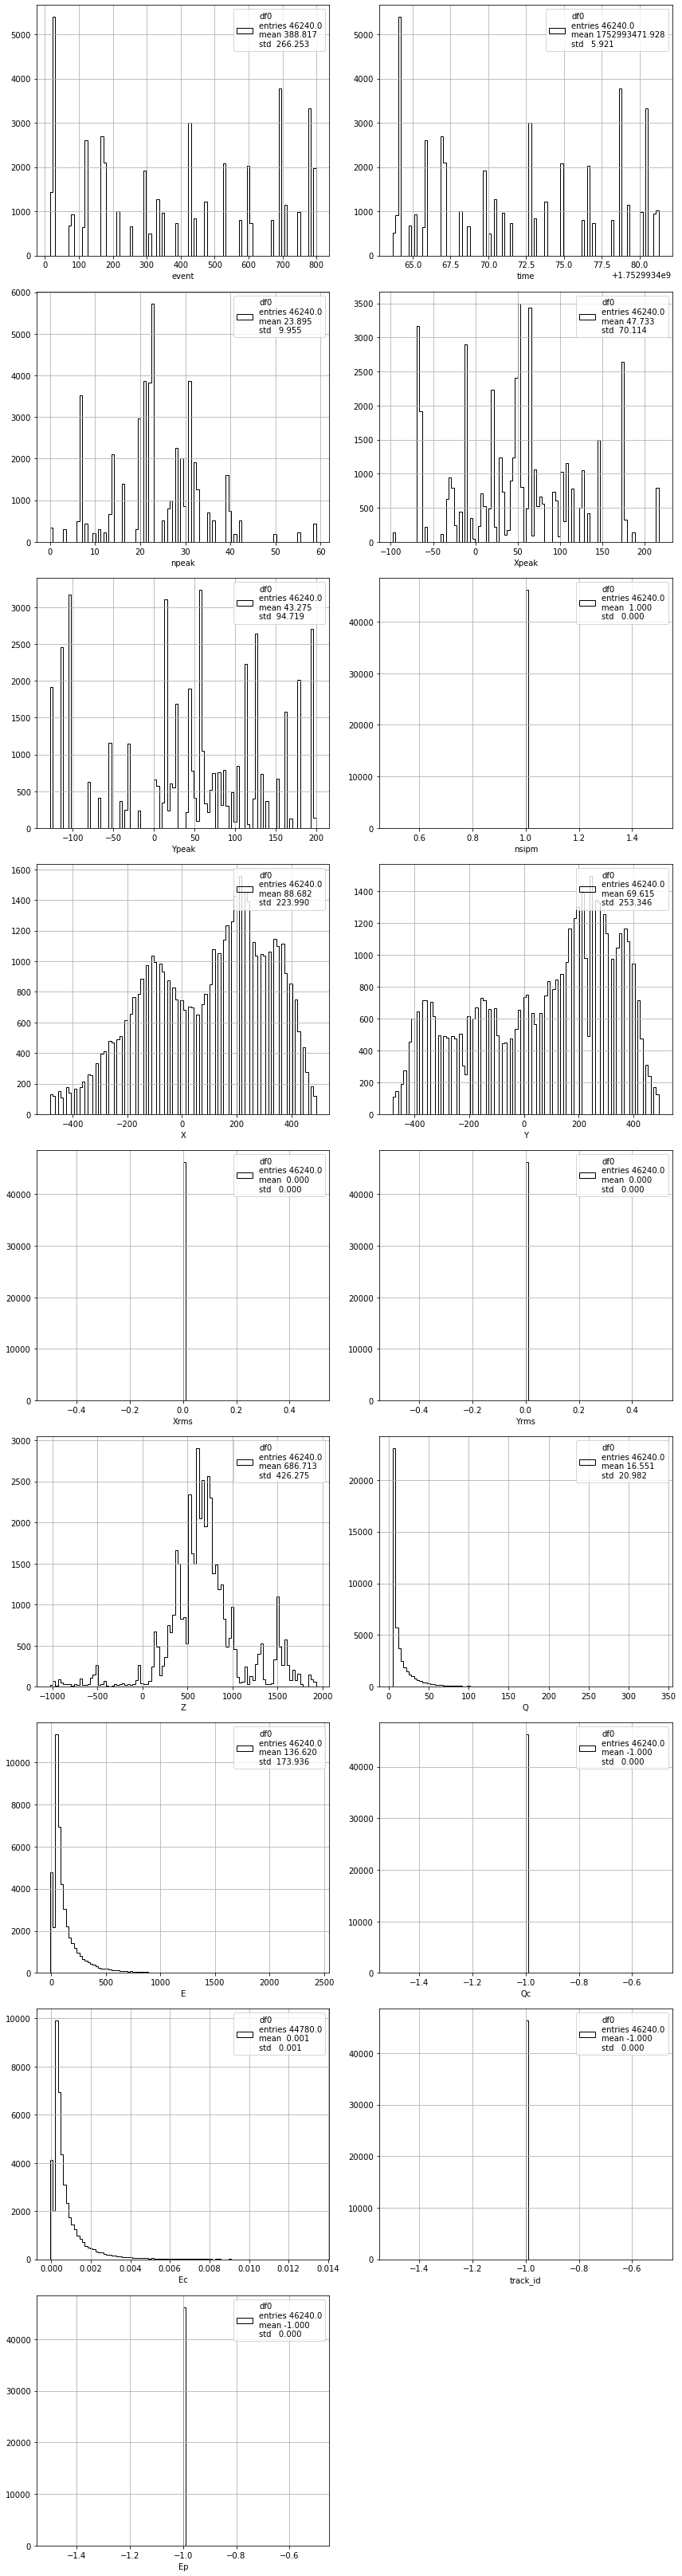

In [12]:
pltext.df_inspect(hits)

In [18]:
import nana.reco.display as pdisplay

In [34]:
events_ids = hits['event'].unique()
ievent     = events_ids[2]
event      =  hits[hits.event == ievent]
len(event)

5393

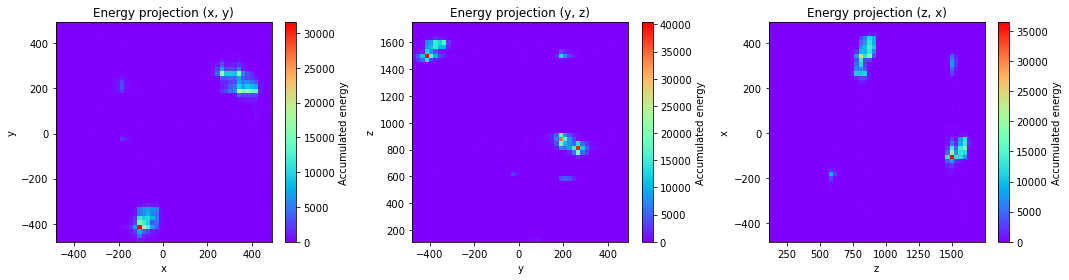

In [35]:
pdisplay.plot_energy_projections(event.X, event.Y, event.Z, event.E)

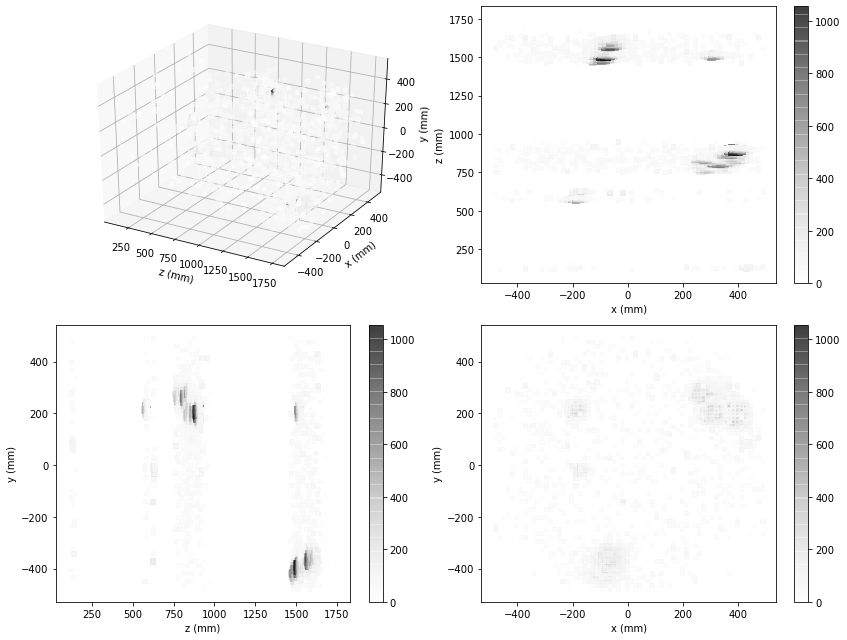

In [36]:
pdisplay.event(event.X, event.Y, event.Z, event.E)

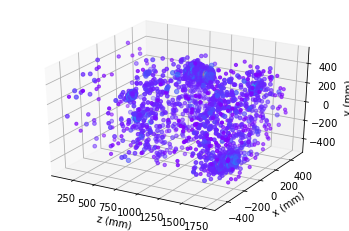

In [37]:
pdisplay.track(event.X, event.Y, event.Z, event.E)